In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from matplotlib import pyplot as plt
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
# Define a transform to convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize with mean and std dev
])

# Load the training dataset|
train_dataset = MNIST(
    root='./data',         # Directory to store the data
    train=True,            # Request the training set
    download=True,         # Download the dataset if not available
    transform=transform    # Apply the defined transform
)

# Load the test dataset
test_dataset = MNIST(
    root='./data',
    train=False,           # Request the test set
    download=True,
    transform=transform
)

# Define DataLoaders to batch and shuffle the data
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True           # Shuffle training data
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False          # No need to shuffle test data
)

In [3]:
train_dataset, test_dataset

(Dataset MNIST
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=(0.5,), std=(0.5,))
            ),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=(0.5,), std=(0.5,))
            ))

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Entrada: 1 canal (P&B), Saída: 32 filtros, Kernel: 3x3
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        # Entrada: 32, Saída: 64 filtros, Kernel: 3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        # Dropout para evitar overfitting
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        # Camadas Lineares (Total de pixels após o pooling: 64 * 14 * 14)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10) # 10 classes para os dígitos 0-9

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        # Reduz a imagem de 28x28 para 14x14
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        # "Achata" a matriz para um vetor
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [5]:
epochs = 10
stop_loss = 1e-3
learning_rate = 1e-3

device = "cuda"
model = SimpleCNN().to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

model.train() # Coloca o modelo em modo de treinamento

for epoch in range(1, epochs + 1):
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        # Enviar dados para GPU ou CPU
        data, target = data.to(device), target.to(device)

        # 1. Zerar os gradientes do otimizador
        optimizer.zero_grad()
        
        # 2. Forward pass (Previsão)
        output = model(data)
        
        # 3. Calcular a perda (Erro)
        loss = loss_fn(output, target)
        
        # 4. Backward pass (Calcular gradientes)
        loss.backward()
        
        # 5. Atualizar pesos
        optimizer.step()

        running_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f"Época: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] "
                  f"Loss: {loss.item():.4f}")

    # Early stopping
    if running_loss/len(train_loader) <= stop_loss:
        print(f"--- Fim do Treinamento {epoch} | Média de Loss: {running_loss/len(train_loader):.4f} ---")
        break
    else:
        print(f"--- Fim da Época {epoch} | Média de Loss: {running_loss/len(train_loader):.4f} ---")

Época: 1 [0/60000] Loss: 2.3057
Época: 1 [51200/60000] Loss: 0.2315
--- Fim da Época 1 | Média de Loss: 0.4541 ---
Época: 2 [0/60000] Loss: 0.1286
Época: 2 [51200/60000] Loss: 0.1091
--- Fim da Época 2 | Média de Loss: 0.1201 ---
Época: 3 [0/60000] Loss: 0.0599
Época: 3 [51200/60000] Loss: 0.0909
--- Fim da Época 3 | Média de Loss: 0.0889 ---
Época: 4 [0/60000] Loss: 0.0951
Época: 4 [51200/60000] Loss: 0.0679
--- Fim da Época 4 | Média de Loss: 0.0736 ---
Época: 5 [0/60000] Loss: 0.0397
Época: 5 [51200/60000] Loss: 0.0500
--- Fim da Época 5 | Média de Loss: 0.0634 ---
Época: 6 [0/60000] Loss: 0.0699
Época: 6 [51200/60000] Loss: 0.0488
--- Fim da Época 6 | Média de Loss: 0.0535 ---
Época: 7 [0/60000] Loss: 0.0485
Época: 7 [51200/60000] Loss: 0.0448
--- Fim da Época 7 | Média de Loss: 0.0475 ---
Época: 8 [0/60000] Loss: 0.0454
Época: 8 [51200/60000] Loss: 0.0638
--- Fim da Época 8 | Média de Loss: 0.0449 ---
Época: 9 [0/60000] Loss: 0.0515
Época: 9 [51200/60000] Loss: 0.0253
--- Fim da É

In [9]:
model.eval()

image, target = train_dataset[55]

print(type(image), image.shape, type(target))

with torch.no_grad():
    image_tensor = image.unsqueeze(0).to(device)
    output = model(image_tensor)
    prediction = output.argmax(dim=1, keepdim=True)
    pred = prediction.item()

    print(target, pred)

<class 'torch.Tensor'> torch.Size([1, 28, 28]) <class 'int'>
8 8


In [10]:
import matplotlib.pyplot as plt

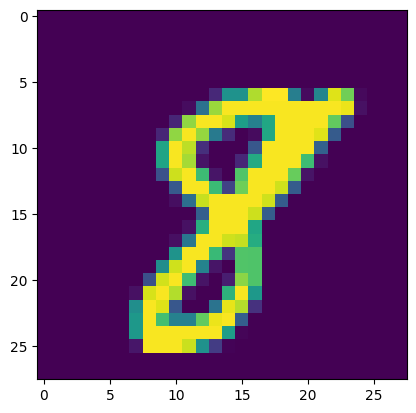

In [11]:
plt.imshow(image.squeeze())

In [52]:


with torch.no_grad():
    image_tensor = image.unsqueeze(0).to(device)
    output = model(image_tensor)
    prediction = output.argmax(dim=1, keepdim=True)
    pred = prediction.item()

In [53]:
for batch_idx, (data, target) in enumerate(train_loader):

    print(batch_idx, data.shape, len(target))

0 torch.Size([512, 1, 28, 28]) 512
1 torch.Size([512, 1, 28, 28]) 512
2 torch.Size([512, 1, 28, 28]) 512
3 torch.Size([512, 1, 28, 28]) 512
4 torch.Size([512, 1, 28, 28]) 512
5 torch.Size([512, 1, 28, 28]) 512
6 torch.Size([512, 1, 28, 28]) 512
7 torch.Size([512, 1, 28, 28]) 512
8 torch.Size([512, 1, 28, 28]) 512
9 torch.Size([512, 1, 28, 28]) 512
10 torch.Size([512, 1, 28, 28]) 512
11 torch.Size([512, 1, 28, 28]) 512
12 torch.Size([512, 1, 28, 28]) 512
13 torch.Size([512, 1, 28, 28]) 512
14 torch.Size([512, 1, 28, 28]) 512
15 torch.Size([512, 1, 28, 28]) 512
16 torch.Size([512, 1, 28, 28]) 512
17 torch.Size([512, 1, 28, 28]) 512
18 torch.Size([512, 1, 28, 28]) 512
19 torch.Size([512, 1, 28, 28]) 512
20 torch.Size([512, 1, 28, 28]) 512
21 torch.Size([512, 1, 28, 28]) 512
22 torch.Size([512, 1, 28, 28]) 512
23 torch.Size([512, 1, 28, 28]) 512
24 torch.Size([512, 1, 28, 28]) 512
25 torch.Size([512, 1, 28, 28]) 512
26 torch.Size([512, 1, 28, 28]) 512
27 torch.Size([512, 1, 28, 28]) 512
28